In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bcf_pressure_profile import HaloProfilePressureBFC
from params_bfc import par as default_par


from scipy.interpolate import RegularGridInterpolator
from integrator import HMCalculatorHarriet

import utils as ut
import pyccl as ccl
import pylab as plt
import matplotlib.cm as cm
from scipy.special import erf
%matplotlib inline

CSV reader of FLAMINGO simulations

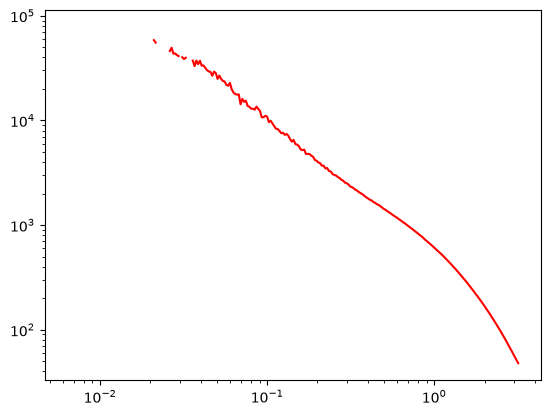

In [ ]:
#flamingo simulation we ran
fname_pk = r"/mnt/extraspace/smaleubre/Flamingo_Analysis/L1000N1800/HYDRO_FIDUCIAL/snap_0077/power_spectrum/nfft_1024/cross_m_density_gas_density_nfft1024.csv"
#simulation from flamingo
fname_pk2 = r"/mnt/extraspace/smaleubre/Flamingo_Analysis/L1000N1800/HYDRO_FIDUCIAL/power_spectra_Flamingo/"


Pk = pd.read_csv(fname_pk, header=9, sep=' ')  
Pk2 = np.loadtxt(fname_pk2+"power_gas-matter_0122.txt", comments='#')

kmin = Pk['kmin'].to_numpy()   
kmax = Pk['kmax'].to_numpy()
power = Pk['power'].to_numpy()

#emissivity corrections
##### PS <ee> 
#power = power * 1*10**(-40)
##### PS <eX>
#power = power * 1*10**(-20)

power2 = Pk2[:,2]

#matter-gas correction
power2 = power2 * (0.306/0.0486)

#gas-gas correction
#power2 = power2 * (0.306/0.0486)**2

average = (kmin + kmax) / 2

average2 = Pk2[:,1]


Loading A. Mead Github 

In [3]:


bnl_data = np.loadtxt(r"/mnt/users/rogers/BNL/data/BNL/M512/MDR1_rockstar_85_bnl.dat")
binstats = np.loadtxt(r"/mnt/users/rogers/BNL/data/BNL/M512/MDR1_rockstar_85_binstats.dat")
kh_bnl = bnl_data[:25, 0]
log10Mh_bins = binstats[:,2]

h = 0.7
log10M_bins = log10Mh_bins - np.log10(h)
k_bnl = kh_bnl * h
lk_bnl = np.log10(k_bnl)

n_k = len(k_bnl)
n_mass = len(log10M_bins) 
F_grid = np.zeros((n_mass, n_mass, n_k))
row_idx = 0
for ibin in range(n_mass):
    for jbin in range(n_mass):
        for ik in range(n_k):
            if ik < 1:
                F_grid [ibin, jbin, ik] = 1
            else:
                F_grid[ibin, jbin, ik] = bnl_data[row_idx, 1]  # Column 1 is 1 + B_NL
            row_idx += 1


Fint_interpolator = RegularGridInterpolator(
    points=(log10M_bins, log10M_bins, lk_bnl),
    values=F_grid,
    method="linear",         # or 'linear' if cubic behaves unstably
    bounds_error=False,
    fill_value= None         # Extrapolation behavior if needed
)


Baryonification

In [4]:


# nM = ccl.halos.MassFuncTinker08(mass_def="200c")
nM = ccl.halos.MassFuncBocquet20(mass_def="200c")
bM = ccl.halos.HaloBiasTinker10(mass_def="200c")
cM = ccl.halos.ConcentrationDuffy08(mass_def="200c")
mv2mt = ut.Mvir2MtotNFWt(concentration_f=cM)
pgas = ut.HaloProfileGasBFCDavid(mass_def="200c", log10Mc=8, mu=0.25, delta=2.0, Mvir2Mtot=mv2mt)


pmat = ccl.halos.HaloProfileNFW(mass_def="200c", concentration=cM, truncated=False)  #added truncated=False for halo particle plots

# Define new halo model calculator using the total mass as normalisation of the gas profile
hmc = ccl.halos.HMCalculator(mass_function=nM, halo_bias=bM, mass_def="200c",
                             log10M_min=10.0, log10M_max=15.0, nM=64)
hmch = HMCalculatorHarriet(mass_function=nM, halo_bias=bM, mass_def="200c",
                             log10M_min=10.0, log10M_max=15.0, nM=64)

# Create the Cosmology object
#D3A cosmology
cosmo_lcdm = ccl.Cosmology(Omega_c=0.2574,   # Cold dark matter density fraction
    Omega_b=0.0486,   # Baryon density fraction
    h=0.681,         # Hubble constant / 100
    #A_s=2.099e-9,     # Primordial amplitude
    n_s=0.967,     # Spectral index
    sigma8 = 0.8215942101867463
    )


#my values
#pgas_bfc = ut.HaloProfilePressureNFWBFCDavid(mass_def="200c", log10Mc=13.15, mu=0.75, delta=5, theta_c0=0.262, ciga0=0.122, Nstar=0.026, eta=0.066, deta=0.215, Mvir2Mtot=mv2mt)
#Michael's values
pgas_bfc = ut.HaloProfilePressureNFWBFCDavid(mass_def="200c", log10Mc=13.268, mu=0.755, delta=4.961, theta_c0=0.262, ciga0=0.122, Nstar=0.026, eta=0.066, deta=0.215,
                                             a0_nth=0.134, n_nth=0.35, b_nth=0.37, Mvir2Mtot=mv2mt)

pgas_bfc.update_precision_fftlog(padding_hi_fftlog=1E2,
                                     padding_lo_fftlog=1E-2,
                                     n_per_decade=500,
                                     plaw_fourier=-2.,
                                     large_padding_2D=True)




k_arr = np.geomspace(1E-5, 1E3, 500)
#k_arr = np.geomspace(1E-2, 1E1, 500)
lk_arr = np.log(k_arr)
z_arr = np.linspace(0, 2, 16)
a_arr = 1/(1+z_arr[::-1])

# matter-matter
# pk_mm_2h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pmat, prof2=pmat, get_1h=False)
# pk_mm_1h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pmat, prof2=pmat, get_2h=False)
# pk_mm = pk_mm_1h + pk_mm_2h 

#matter-gas
pk_mg_2h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmch, k_arr, 1.0, pmat, prof2=pgas, get_1h=False)
pk_mg_1h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmch, k_arr, 1.0, pmat, prof2=pgas, get_2h=False)
pk_mg = pk_mg_1h + pk_mg_2h

#gas-gas
# pk_gg_2h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pgas, prof2=pgas, get_1h=False)
# pk_gg_1h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pgas, prof2=pgas, get_2h=False)
# pk_gg = pk_gg_1h + pk_gg_2h

# pressure BFC
# pk_mg_bfc_2h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pmat, prof2=pgas_bfc, get_1h=False)
# pk_mg_bfc_1h = ccl.halos.pk_2pt.halomod_power_spectrum(cosmo_lcdm, hmc, k_arr, 1.0, pmat, prof2=pgas_bfc, get_2h=False)
# pk_mg_bfc = pk_mg_bfc_2h + pk_mg_bfc_1h



Add in corrections for A. Mead

In [5]:
# pressure BFC integrator
# int_mg_bfc_2 = hmch.integrate_2d(pmat, pgas_bfc, Fint_interpolator, k_arr, 1.0, cosmo_lcdm,
#                                  interp_ranges=[log10M_bins[0], log10M_bins[-1], lk_bnl[0], lk_bnl[-1]])
# pk_mg_bfc_2h_b = (int_mg_bfc_2 * ccl.linear_matter_power(cosmo_lcdm, k_arr, 1.0)) + pk_mg_bfc_1h


#matter-gas integrator
int_mg = hmch.integrate_2d(pmat, pgas, Fint_interpolator, k_arr, 1.0, cosmo_lcdm,
                                 interp_ranges=[log10M_bins[0], log10M_bins[-1], lk_bnl[0], lk_bnl[-1]])
pk_mg_b = (int_mg * ccl.linear_matter_power(cosmo_lcdm, k_arr, 1.0)) + pk_mg_1h

#matter-matter integrator
# int_mm = hmch.integrate_2d(pmat, pmat, Fint_interpolator, k_arr, 1.0, cosmo_lcdm,
#                                  interp_ranges=[log10M_bins[0], log10M_bins[-1], lk_bnl[0], lk_bnl[-1]])
# pk_mm_b = (int_mm * ccl.linear_matter_power(cosmo_lcdm, k_arr, 1.0)) + pk_mm_1h

#gas-gas integrator
# int_gg = hmch.integrate_2d(pgas, pgas, Fint_interpolator, k_arr, 1.0, cosmo_lcdm,
#                                  interp_ranges=[log10M_bins[0], log10M_bins[-1], lk_bnl[0], lk_bnl[-1]])
# pk_gg_b = (int_gg * ccl.linear_matter_power(cosmo_lcdm, k_arr, 1.0)) + pk_gg_1h

Plotting

0.10696996056740511


Text(0.5, 1.0, 'HYDRO_FIDUCIAL')

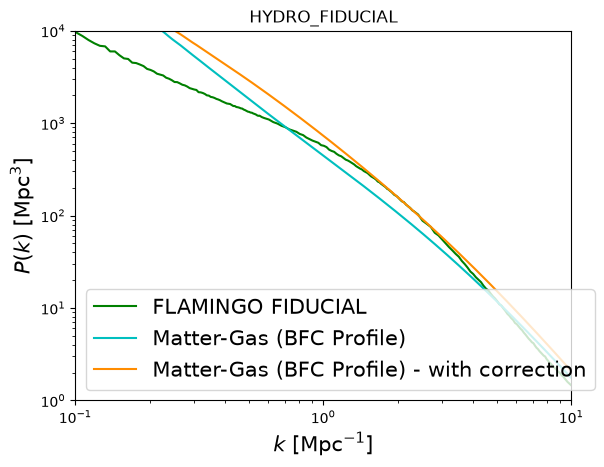

In [6]:
plt.figure()
# plt.plot(average, power, 'b-', label='FLAMINGO FIDUCIAL')
plt.plot(average2, power2, 'g-', label='FLAMINGO FIDUCIAL')
plt.xscale('log')
plt.yscale('log')
#plt.plot(k1, pk_MM, 'r-', label='CCL')
#plt.plot(k_arr, pk_mm(k_arr, 1.0), label='matter-matter') 
#plt.plot(k_arr, pk_gg(k_arr, 1.0), label='gas-gas') 
#plt.plot(k_arr, pk_mg(k_arr, 1.0), label='matter-gas')


#plt.plot(k_arr, pk_mg_bfc(k_arr, 1.0), label='Matter-Pressure (BFC Profile)')
#plt.plot(k_arr, pk_mg_bfc, label='Matter-Pressure (BFC Profile)')
#plt.plot(k_arr, pk_mg_bfc_2h_b, label='Matter-Pressure (BFC Profile) - with correction')
plt.plot(k_arr, pk_mg, 'c-', label='Matter-Gas (BFC Profile)')
plt.plot(k_arr, pk_mg_b, 'darkorange', label='Matter-Gas (BFC Profile) - with correction')
# plt.plot(k_arr, pk_mm, 'c-', label='Matter-Matter (BFC Profile)')
# plt.plot(k_arr, pk_mm_b, 'darkorange', label='Matter-Matter (BFC Profile) - with correction')
# plt.plot(k_arr, pk_gg, 'c-', label='Gas-Gas (BFC Profile)')
# plt.plot(k_arr, pk_gg_b, 'darkorange', label='Gas-Gas (BFC Profile) - with correction')

diff = (pk_mg_b - pk_mg)/pk_mg
diff = np.mean(diff)
print(diff)


plt.legend(loc='lower left', fontsize=15)
plt.ylabel(r'$P(k)\,\,[{\rm Mpc}^3]$', fontsize=15)
plt.xlabel(r'$k\,\,[{\rm Mpc}^{-1}]$', fontsize=15)
#plt.xlim(1E-3, 1E2)
plt.xlim(1E-1, 1E1)
#plt.ylim(bottom=1E-5)
plt.ylim(1, 1E4)
plt.title('HYDRO_FIDUCIAL')